### Labsheet 2 SECS05-AS01
### Mastery in Data Analytics and Visualizations and Career Advancement
#### Khushi Choudhary CU240251564

In [ ]:
# Khushi Choudhary CU240251564
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)
# Load dataset
df = pd.read_csv("Sample - Superstore.csv", encoding="windows-1252")
print("Dataset loaded successfully!")

Dataset loaded successfully!


In [4]:
# 1. Dimensions and columns
print(f"Dataset Shape: {df.shape}")
print("\n--- Column Info ---")
df.info()
# 2. Summary statistics of numerical columns
print("\n--- Numerical Summary ---")
print(df[["Sales", "Quantity", "Discount", "Profit"]].describe())
# 3. Frequency of categorical features
print("\n--- Top Segments ---")
print(df["Segment"].value_counts())

Dataset Shape: (9994, 21)

--- Column Info ---
<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9

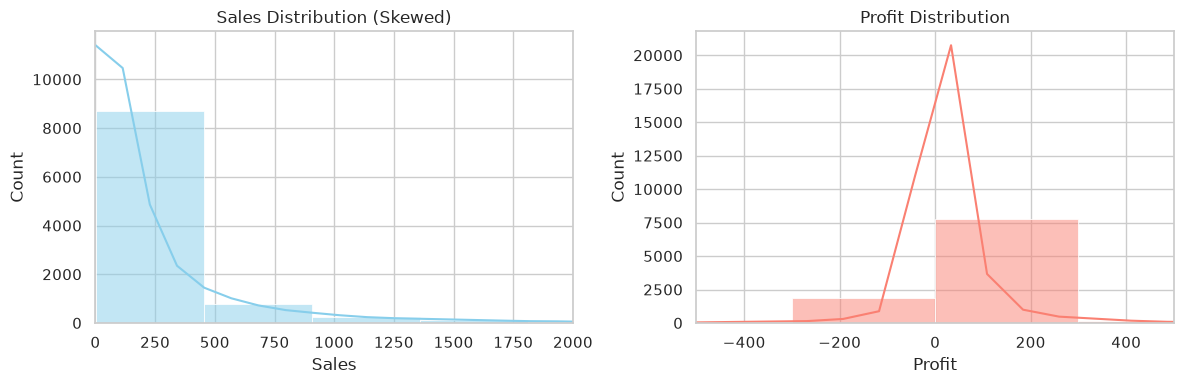

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# Sales distribution
sns.histplot(df["Sales"], bins=50, kde=True, ax=axes[0], color="skyblue")
axes[0].set_title("Sales Distribution (Skewed)")
axes[0].set_xlim(0, 2000)  # Zoom in to see main density
# Profit distribution
sns.histplot(df["Profit"], bins=50, kde=True, ax=axes[1], color="salmon")
axes[1].set_title("Profit Distribution")
axes[1].set_xlim(-500, 500)
plt.tight_layout()
plt.show()

/tmp/ipykernel_8264/445248357.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Category", ax=axes[0], palette="Set2")
/tmp/ipykernel_8264/445248357.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Region", ax=axes[1], palette="Set3")


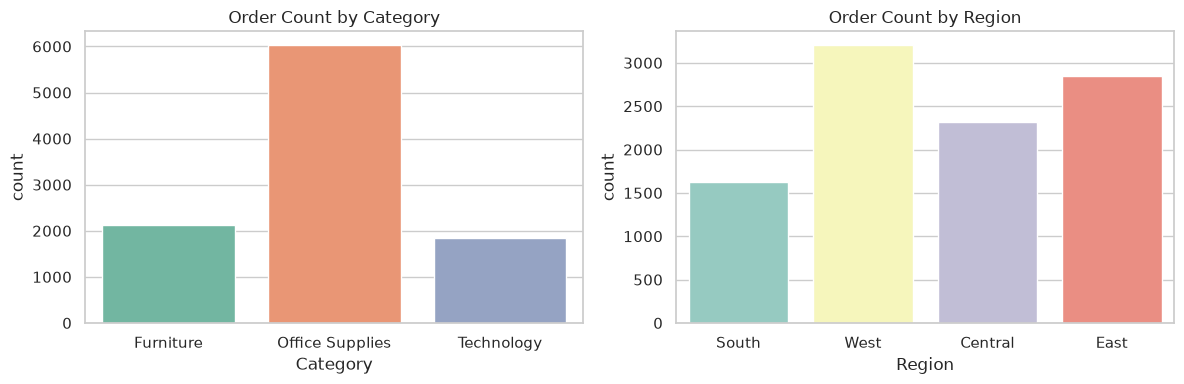

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# Category distribution
sns.countplot(data=df, x="Category", ax=axes[0], palette="Set2")
axes[0].set_title("Order Count by Category")
# Region distribution
sns.countplot(data=df, x="Region", ax=axes[1], palette="Set3")
axes[1].set_title("Order Count by Region")
plt.tight_layout()
plt.show()

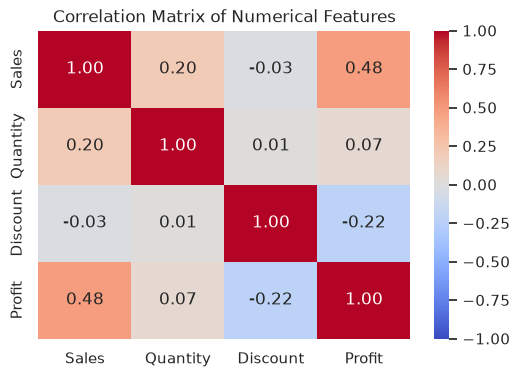

In [7]:
# Select numeric columns
numeric_cols = ["Sales", "Quantity", "Discount", "Profit"]
corr_matrix = df[numeric_cols].corr()
plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Matrix of Numerical Features")
plt.show()

/tmp/ipykernel_8264/4195826548.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Category", y="Profit", ax=axes[0], palette="pastel")


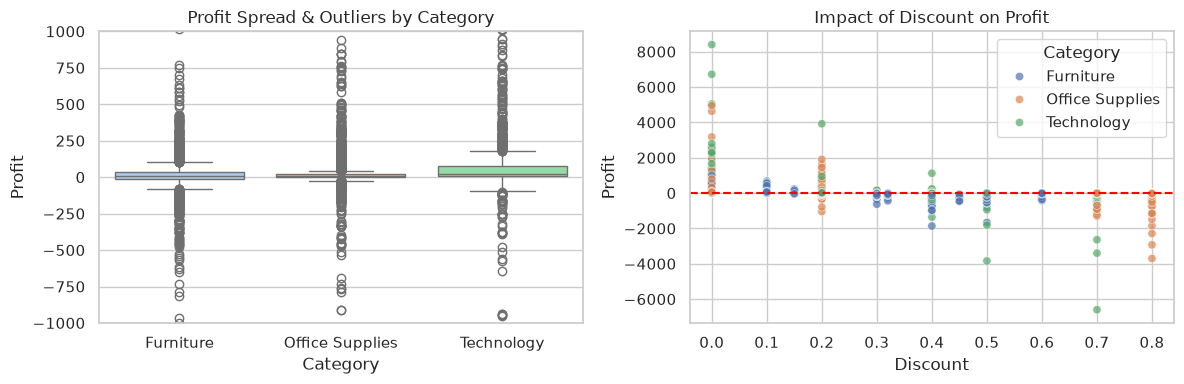

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# Boxplot for outlier detection in Sales across Categories
sns.boxplot(data=df, x="Category", y="Profit", ax=axes[0], palette="pastel")
axes[0].set_title("Profit Spread & Outliers by Category")
axes[0].set_ylim(-1000, 1000)
# Scatter plot: Discount vs Profit
sns.scatterplot(data=df, x="Discount", y="Profit", hue="Category", alpha=0.7, ax=axes[1])
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_title("Impact of Discount on Profit")
plt.tight_layout()
plt.show()

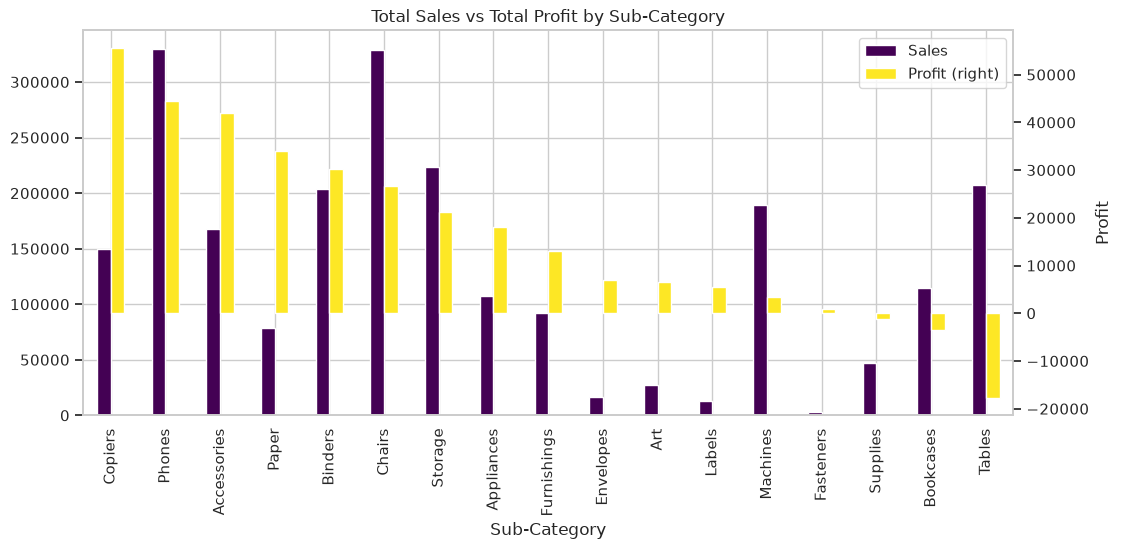

In [ ]:
# Khushi Choudhary CU240251564
# Sales and Profit by Sub-Category
sub_cat_summary = (
    df.groupby("Sub-Category")[["Sales", "Profit"]]
    .sum()
    .sort_values(by="Profit", ascending=False)
)
sub_cat_summary.plot(kind="bar", figsize=(12, 5), secondary_y="Profit", colormap="viridis")
plt.title("Total Sales vs Total Profit by Sub-Category")
plt.ylabel("Profit")
plt.show()

### Step 9: Key Observations & Business Insights

* **Discount vs. Profit Impact:** Higher discounts (> 20%) show a direct correlation with negative profit margins.
* **Category Performance:** 
  * **Technology** generates the highest total profit and strongest margins.
  * **Furniture** (specifically Tables and Bookcases) operates at thin or negative margins due to steep discounts.
* **Customer Distribution:** The **Consumer** segment accounts for the highest volume of total orders and overall sales.
* **Outliers:** The Sales and Profit distributions are highly right-skewed with significant high-value outliers (e.g., bulk technology purchases).

### Step 10: Final Report & Recommendations

1. **Discount Cap Policy:** Introduce an upper limit on discounts for loss-making sub-categories (like Tables and Bookcases) to prevent margin leakage.
2. **Promotional Focus:** Reallocate marketing budget toward high-margin items such as Phones, Accessories, and Copiers.
3. **Regional Fulfillment:** Re-evaluate regional delivery channels with low return-on-sales to optimize logistics expenses.